In [1]:
# Step 1: Install required packages
!pip install streamlit scikit-learn xgboost mlflow pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 115.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.9/753.9 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.6 MB/s eta 0:00:00


In [2]:
# Step 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
import mlflow
import mlflow.sklearn
import streamlit as st
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

#Load data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Step 3: Data Loading and Preprocessing
@st.cache_data
def load_and_preprocess_data():
    # In Colab, upload the file or use from drive
    # For now, assume uploaded as 'emi_prediction_dataset.csv'
    df = pd.read_csv('/content/drive/MyDrive/EMIPredict AI - Intelligent Financial Risk Assessment Platform/emi_prediction_dataset.csv', low_memory=False)

    # Convert types
    df['age'] = pd.to_numeric(df['age'], errors='coerce')
    df['monthly_salary'] = pd.to_numeric(df['monthly_salary'], errors='coerce')
    df['bank_balance'] = pd.to_numeric(df['bank_balance'], errors='coerce')

    # Impute missing values
    numerical_cols = ['age', 'monthly_salary', 'monthly_rent', 'credit_score', 'bank_balance', 'emergency_fund']
    for col in numerical_cols:
        df[col] = df[col].fillna(df[col].median())

    df['education'] = df['education'].fillna(df['education'].mode()[0])

    # Clean gender
    df['gender'] = df['gender'].str.upper().str.strip()
    df['gender'] = df['gender'].replace({'M': 'MALE', 'F': 'FEMALE', 'M.': 'MALE', 'F.': 'FEMALE'})

    # Check for duplicates
    df = df.drop_duplicates()

    return df

df = load_and_preprocess_data()
print(f"Dataset shape: {df.shape}")



2025-11-12 11:17:23.453 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2025-11-12 11:17:23.460 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2025-11-12 11:17:23.464 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-12 11:17:24.046 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-11-12 11:17:24.049 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-12 11:17:24.052 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-12 11:17:24.055 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-12 11:17:24.559 Thread 'Thread-4': missing 

Dataset shape: (404800, 27)


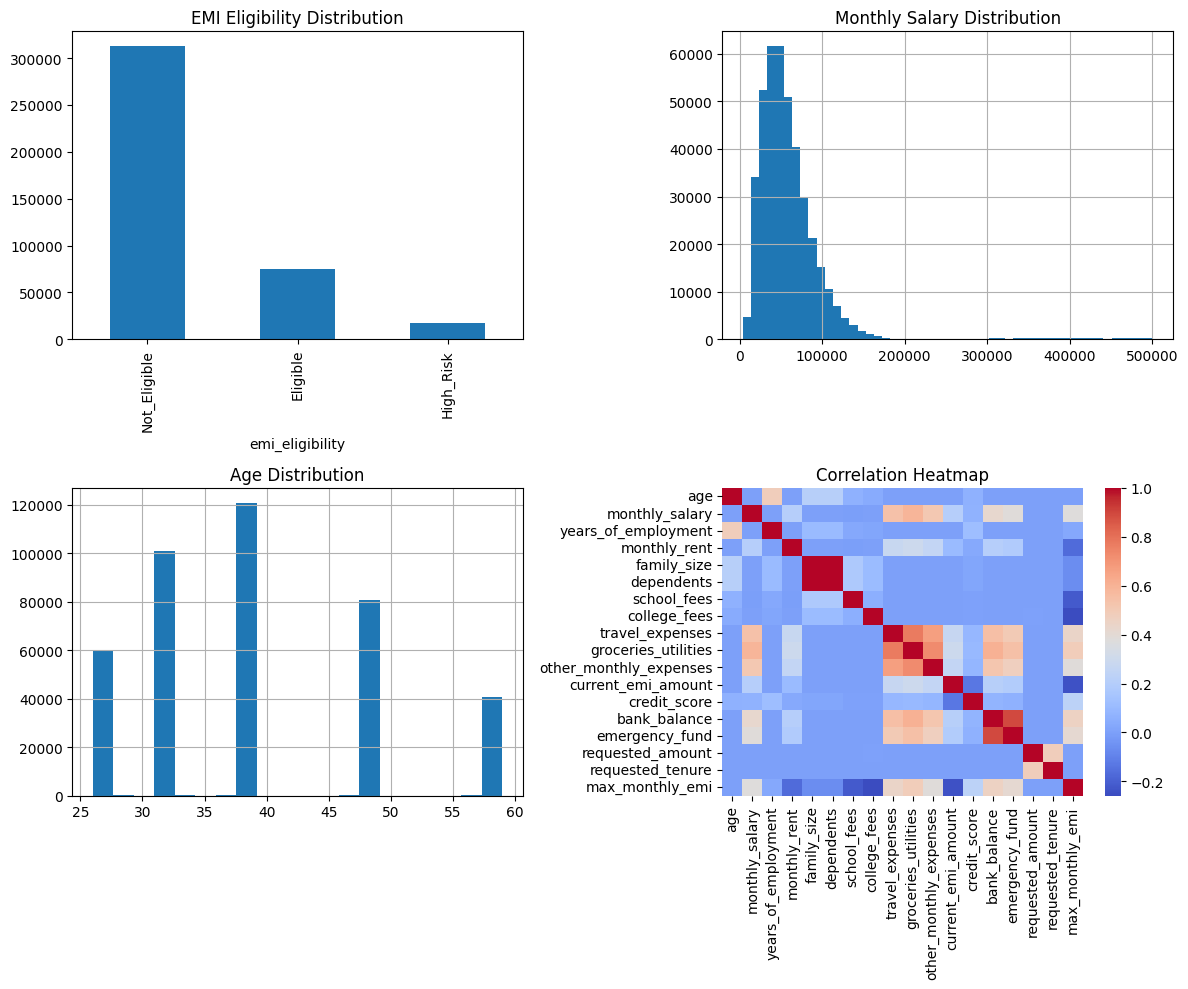

EMI Eligibility Distribution:
emi_eligibility
Not_Eligible    0.772895
Eligible        0.183903
High_Risk       0.043202
Name: proportion, dtype: float64

Correlation with max_monthly_emi:
max_monthly_emi           1.000000
groceries_utilities       0.484695
bank_balance              0.456028
travel_expenses           0.440948
emergency_fund            0.414036
other_monthly_expenses    0.382055
monthly_salary            0.378284
credit_score              0.228814
years_of_employment       0.028887
requested_tenure          0.001006
age                      -0.000848
requested_amount         -0.002034
dependents               -0.062266
family_size              -0.062266
monthly_rent             -0.169423
school_fees              -0.215234
current_emi_amount       -0.242434
college_fees             -0.258842
Name: max_monthly_emi, dtype: float64


In [4]:
# Step 4: Exploratory Data Analysis
def perform_eda(df):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # EMI eligibility distribution
    df['emi_eligibility'].value_counts().plot(kind='bar', ax=axes[0,0])
    axes[0,0].set_title('EMI Eligibility Distribution')

    # Monthly salary distribution
    df['monthly_salary'].hist(bins=50, ax=axes[0,1])
    axes[0,1].set_title('Monthly Salary Distribution')

    # Age distribution
    df['age'].hist(bins=20, ax=axes[1,0])
    axes[1,0].set_title('Age Distribution')

    # Correlation heatmap for numerical
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    corr = df[numerical_cols].corr()
    sns.heatmap(corr, ax=axes[1,1], cmap='coolwarm')
    axes[1,1].set_title('Correlation Heatmap')

    plt.tight_layout()
    plt.show()

    # Print insights
    print("EMI Eligibility Distribution:")
    print(df['emi_eligibility'].value_counts(normalize=True))

    print("\nCorrelation with max_monthly_emi:")
    print(corr['max_monthly_emi'].sort_values(ascending=False))

perform_eda(df)

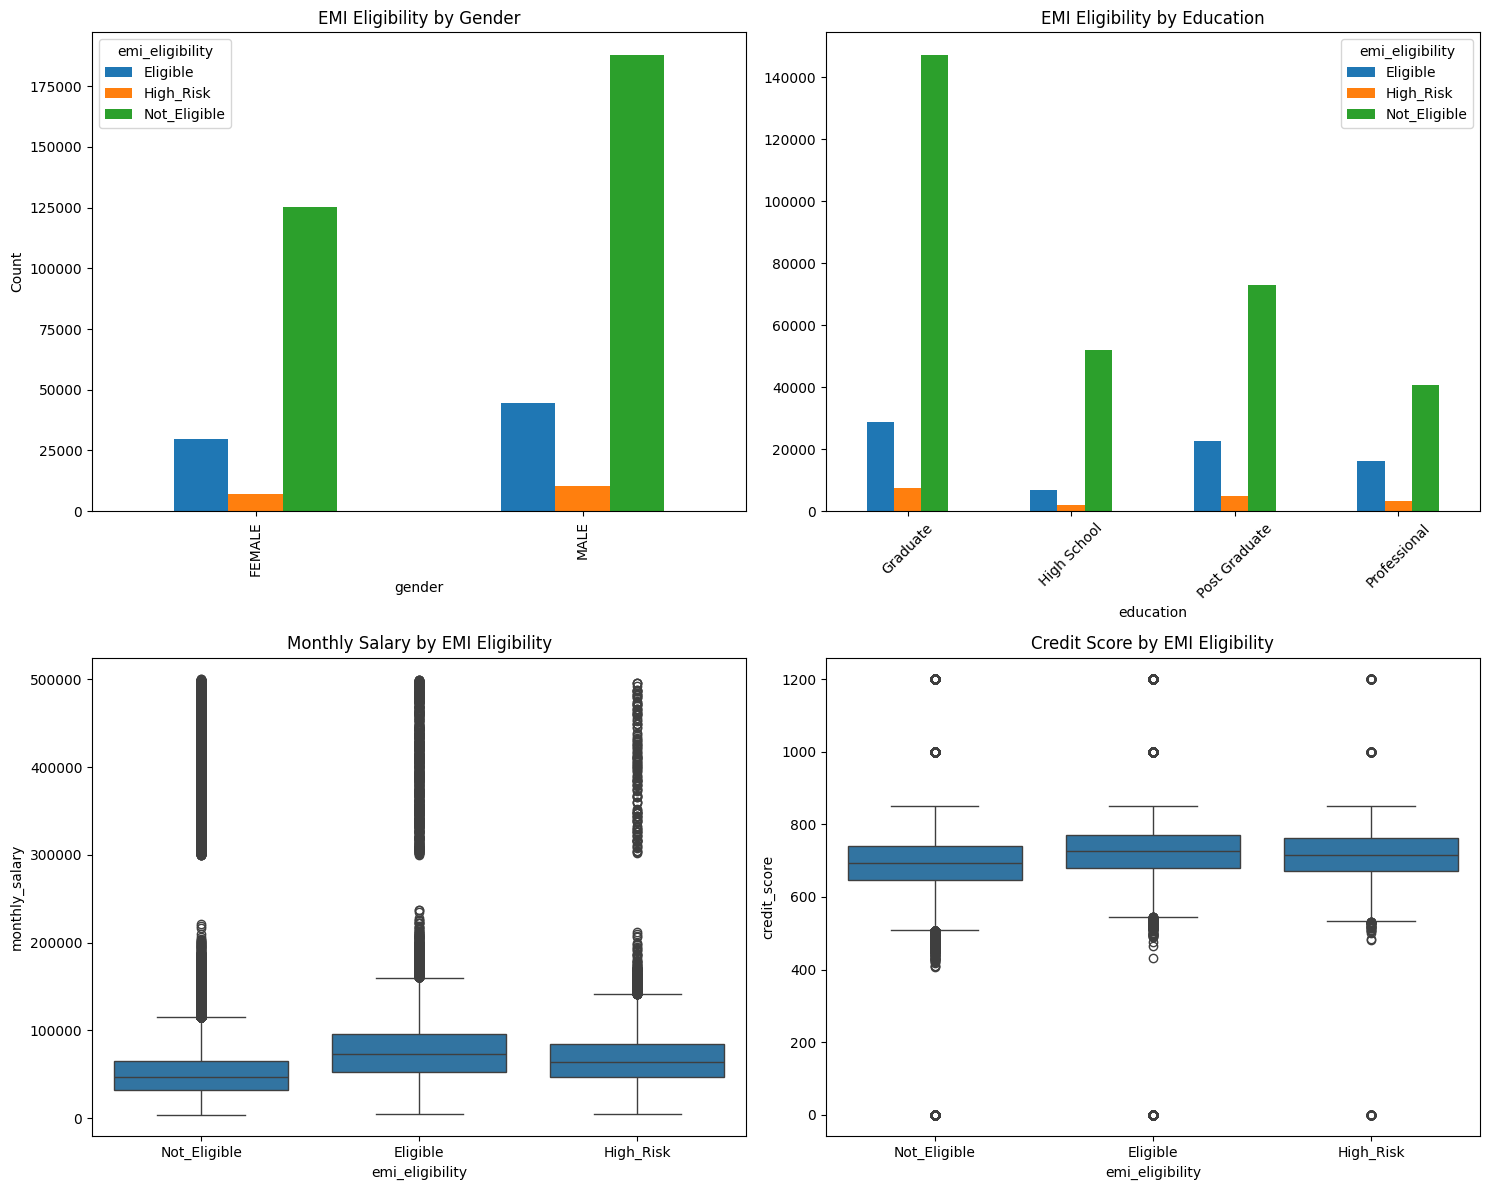

In [6]:
# 6.4 Demographic Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gender vs EMI Eligibility
gender_eligibility = pd.crosstab(df['gender'], df['emi_eligibility'])
gender_eligibility.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('EMI Eligibility by Gender')
axes[0,0].set_ylabel('Count')

# Education vs EMI Eligibility
education_eligibility = pd.crosstab(df['education'], df['emi_eligibility'])
education_eligibility.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('EMI Eligibility by Education')
axes[0,1].tick_params(axis='x', rotation=45)

# Monthly Salary vs Eligibility
sns.boxplot(data=df, x='emi_eligibility', y='monthly_salary', ax=axes[1,0])
axes[1,0].set_title('Monthly Salary by EMI Eligibility')

# Credit Score vs Eligibility
sns.boxplot(data=df, x='emi_eligibility', y='credit_score', ax=axes[1,1])
axes[1,1].set_title('Credit Score by EMI Eligibility')

plt.tight_layout()
plt.show()

In [7]:
# Step 5: Feature Engineering
def feature_engineering(df):
    # Total monthly expenses
    df['total_monthly_expenses'] = (df['school_fees'] + df['college_fees'] + df['travel_expenses'] +
                                    df['groceries_utilities'] + df['other_monthly_expenses'] + df['monthly_rent'].fillna(0))

    # Debt to Income Ratio
    df['dti_ratio'] = (df['current_emi_amount'] + df['total_monthly_expenses']) / df['monthly_salary']

    # Affordability Ratio
    df['affordability_ratio'] = (df['monthly_salary'] - df['total_monthly_expenses'] - df['current_emi_amount']) / df['monthly_salary']

    # Risk Score
    df['risk_score'] = df['credit_score'] - df['existing_loans'].map({'Yes': 100, 'No': 0}).fillna(0)

    # Categorical encoding
    cat_cols = ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario']
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    return df

df = feature_engineering(df)
print(f"Features after engineering: {df.shape[1]}")

# Encode targets
le_class = LabelEncoder()
df['emi_eligibility_encoded'] = le_class.fit_transform(df['emi_eligibility'])
print("Class labels:", le_class.classes_)

Features after engineering: 41
Class labels: ['Eligible' 'High_Risk' 'Not_Eligible']


In [8]:
# Step 6: Machine Learning Model Development
# Split data (use full or sample for speed; here sample 10%)
df_sample = df.sample(frac=0.1, random_state=42)
feature_cols = [col for col in df_sample.columns if col not in ['emi_eligibility', 'max_monthly_emi', 'emi_eligibility_encoded']]

X = df_sample[feature_cols]
y_class = df_sample['emi_eligibility_encoded']
y_reg = df_sample['max_monthly_emi']

X_train, X_test, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)
_, _, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
num_cols = X.select_dtypes(include=[np.number]).columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Classification Models
class_models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=100)
}

class_results = {}
for name, model in class_models.items():
    model.fit(X_train, y_train_class)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_class, y_pred)
    class_results[name] = {'model': model, 'accuracy': acc}
    print(f"{name} Accuracy: {acc:.4f}")

# Best classification model
best_class_name = max(class_results, key=lambda k: class_results[k]['accuracy'])
best_class_model = class_results[best_class_name]['model']
print(f"Best Classification Model: {best_class_name} with accuracy {class_results[best_class_name]['accuracy']:.4f}")

# Regression Models
reg_models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=100),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=100)
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train, y_train_reg)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2 = r2_score(y_test_reg, y_pred)
    reg_results[name] = {'model': model, 'rmse': rmse, 'r2': r2}
    print(f"{name} RMSE: {rmse:.2f}, R2: {r2:.4f}")

# Best regression model
best_reg_name = min(reg_results, key=lambda k: reg_results[k]['rmse'])
best_reg_model = reg_results[best_reg_name]['model']
print(f"Best Regression Model: {best_reg_name} with RMSE {reg_results[best_reg_name]['rmse']:.2f}")

LogisticRegression Accuracy: 0.8888
RandomForest Accuracy: 0.9223
XGBoost Accuracy: 0.9541
Best Classification Model: XGBoost with accuracy 0.9541
LinearRegression RMSE: 7677.33, R2: -0.0012
RandomForest RMSE: 7812.21, R2: -0.0367
XGBoost RMSE: 7967.56, R2: -0.0783
Best Regression Model: LinearRegression with RMSE 7677.33


In [12]:
# Step 7: MLflow Integration
mlflow.set_experiment("EMI_Prediction_Experiment")

with mlflow.start_run(run_name="Classification_Models_Tracking"):
    for name, res in class_results.items():
        with mlflow.start_run(run_name=f"Classification_{name}", nested=True):
            mlflow.log_param("model_type", name)
            mlflow.log_metric("accuracy", res['accuracy'])
            # Addressing warnings: using 'name' and adding 'input_example'
            mlflow.sklearn.log_model(res['model'], name=f"model_{name}", input_example=X_train.head(1))

with mlflow.start_run(run_name="Regression_Models_Tracking"):
    for name, res in reg_results.items():
        with mlflow.start_run(run_name=f"Regression_{name}", nested=True):
            mlflow.log_param("model_type", name)
            mlflow.log_metric("rmse", res['rmse'])
            mlflow.log_metric("r2", res['r2'])
            # Addressing warnings: using 'name' and adding 'input_example'
            mlflow.sklearn.log_model(res['model'], name=f"model_{name}", input_example=X_train.head(1))

**Note:**

1.  Click the ngrok link above to access the MLflow Tracking UI.
2.  Keep this cell running in the background while you log runs.
3.  You might need to create an ngrok account and add your authtoken for persistent access or if free tier limits are reached. You can set the authtoken in the cell above.
4.  If you encounter issues, try running `ngrok.kill()` in a new cell and re-run the above cell.

In [13]:
app_code = '''
import streamlit as st
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load models (in production, load from mlflow or pickle)
# For demo, assume pickled
# with open('best_class_model.pkl', 'rb') as f:
#     best_class_model = pickle.load(f)
# with open('scaler.pkl', 'rb') as f:
#     scaler = pickle.load(f)
# etc.

st.title("EMIPredict AI - Financial Risk Assessment")

# Sidebar for inputs
st.sidebar.header("Financial Profile")
age = st.sidebar.slider("Age", 25, 60, 38)
monthly_salary = st.sidebar.number_input("Monthly Salary (INR)", 15000, 200000, 50000)
# Add more inputs for all features... (simplified)

emi_scenario = st.sidebar.selectbox("EMI Scenario", ["E-commerce Shopping EMI", "Home Appliances EMI", "Vehicle EMI", "Personal Loan EMI", "Education EMI"])
requested_amount = st.sidebar.number_input("Requested Amount (INR)", 10000, 1500000, 100000)
requested_tenure = st.sidebar.slider("Requested Tenure (months)", 3, 84, 24)

if st.sidebar.button("Predict"):
    # Prepare input df
    input_df = pd.DataFrame({
        'age': [age],
        'monthly_salary': [monthly_salary],
        # Add all features...
        'requested_amount': [requested_amount],
        'requested_tenure': [requested_tenure],
        # Encode categoricals...
    })

    # Transform
    # input_df[num_cols] = scaler.transform(input_df[num_cols])
    # input_encoded = pd.get_dummies(input_df, ...)  # Match training

    # Predict
    eligibility = best_class_model.predict(input_df)[0]
    max_emi = best_reg_model.predict(input_df)[0]

    st.header("Prediction Results")
    st.write(f"EMI Eligibility: {le_class.inverse_transform([eligibility])[0]}")
    st.write(f"Max Monthly EMI: {max_emi:.2f} INR")

# For full app, add more pages with st.pages
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("Streamlit app code saved to app.py")

Streamlit app code saved to app.py
